# Ecuación de Euler - Euler BEam Equation
## Usando OperatodBC
## Non-standard boundary conditions

Recordar que para resolver cualquier ecuacion diferencial es muy importante tener claro las condiciones de frontera para llegar a la solución correcta.
Las condiciones de frontera actúan como reglas que guian la solucion a hacer match con el mundo real.

Algunos ejemplos serian:
1. Higher - Order Boundary Conditions
$$u''(1)=0,\qquad u'''(1)=0$$
2. Nonlinear Boundary Conditions
$$u'(1)+u(1)^2=0,$$
3. Mixed-Type Conditions
$$u'(0)+\sin(u(1))=0,$$

Este tipo de condiciones no puede ser usado por ninguna forma estandar.


## Problem Setup

The Euler beam problem:

$$\frac{\partial u^4}{\partial x^4}+1=0,\qquad\qquad x\in[0,1]$$


Con las siguientes condiciones de frontera:<br>
- Dirichler on the left boundary $$u(0)=0$$
- One Neumann boundary condition on the left boundary $$u'(0)=0$$
- Two boundary conditions on the right boundary $$u''(1)=0,\qquad u'''(1)=0$$

Esta es una ecuación comun en el campo de la ingenieria mecánica y describe la desviación(bending) de un rayo. u representa el desplazamiento del rayo como funcion de la coordenada espacial x.

La solución exacta es:
$$ u(x)=-\frac{1}{24}x^4+\frac{1}{6}x^3-\frac{1}{4}x^2$$

In [1]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
dde.backend.backend_name = "pytorch"

2025-05-28 11:00:15.762742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748451615.988604    2915 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748451616.055181    2915 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-28 11:00:16.571470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples

In [2]:
import torch as tr
import tensorflow as tf

In [9]:
def pde(x, y):
    dy_xx    = dde.grad.hessian(y,x)      # d2u/dx2
    dy_dxxxx = dde.grad.hessian(dy_xx,x)  # d4u/dx4
    return dy_dxxxx + 1

In [10]:
## Exact solution
def func(x):
    return - x**4 / 24. + x**3 / 6. - x**2 / 4.


In [11]:
## Dirichlet and Neumann Conditions
# En este caso, debido a la peculiaridad de que neuman y dirichlet ambas zero en x=0, por el planteamiento del
# problema, en ambos casos, se usa la misma función.

def boundary_value_l(x):
    return 0

def boundary_l(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],0)


## Custom boundary conditions

## Main PINN Model

In [12]:
geom = dde.geometry.Interval(0,1)

In [13]:
bc_dbc = dde.icbc.DirichletBC(geom, boundary_value_l, boundary_l)
bc_nbc = dde.icbc.NeumannBC(geom, boundary_value_l, boundary_l)


# Operator Boundary Condition

In [14]:
def ddy(x,y):
    return dde.grad.hessian(y,x)

def dddy(x,y):
    return dde.grad.jacobian(ddy(x,y),x)

def boundary_second_derivative(x,y,_):
    return ddy(x,y)

def boundary_third_derivative(x,y,_):
    return dddy(x,y)

def boundary_r(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],1)

In [15]:
bc_obc1 = dde.icbc.OperatorBC(geom, boundary_second_derivative, boundary_r)
bc_obc2 = dde.icbc.OperatorBC(geom, boundary_third_derivative, boundary_r)


In [16]:
## Data model:
data = dde.data.PDE(geom,
                    pde,
                    [bc_dbc,bc_nbc,bc_obc1,bc_obc2],
                    16,         # No of collocation points
                    2,          ## SON PNTOS EN LA FRONTERA, NO NUMERO DE BC. POR ESO ES 2 NO 4.
                    solution=func,
                    num_test=100
                   )

In [17]:
layer_size = [1] + [50]*3 + [1]
# [1]: x input layer
# [50]*3: 3 capas ocultas con 50 neuronas
# [1]: y output layer
activation = "tanh"
initializer = "Glorot uniform"

## FNN Fully conected neural network
net = dde.nn.FNN(layer_size,
                activation,
                initializer
                )

model = dde.Model(data,net)
model.compile("adam",lr=1e-3,metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations = 5000)

Compiling model...
'compile' took 0.044084 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
0         [9.08e-01, 0.00e+00, 5.37e-02, 4.11e-03, 1.16e-03]    [9.06e-01, 0.00e+00, 5.37e-02, 4.11e-03, 1.16e-03]    [1.02e+00]    
1000      [1.05e-04, 6.07e-07, 3.89e-06, 1.44e-08, 9.07e-07]    [9.61e-05, 6.07e-07, 3.89e-06, 1.44e-08, 9.07e-07]    [2.22e-02]    
2000      [5.95e-05, 1.46e-10, 7.27e-09, 1.86e-08, 4.14e-09]    [5.54e-05, 1.46e-10, 7.27e-09, 1.86e-08, 4.14e-09]    [1.98e-03]    
3000      [4.72e-05, 4.05e-09, 9.30e-08, 1.51e-10, 4.76e-10]    [4.38e-05, 4.05e-09, 9.30e-08, 1.51e-10, 4.76e-10]    [1.53e-03]    
4000      [4.45e-05, 4.75e-08, 7.24e-11, 2.95e-09, 1.48e-07]    [3.80e-05, 4.75e-08, 7.24e-11, 2.95e-09, 1.48e-07]    [4.49e-03]    
5000      [3.21e-05, 4.57e-11, 4.79e-11, 9.17e-09, 1.21e-09]    [3.05e-05, 4.57e-11, 4.79e-11, 9.17e-09, 1.21e-09]    [1.93e-03]    

Bes

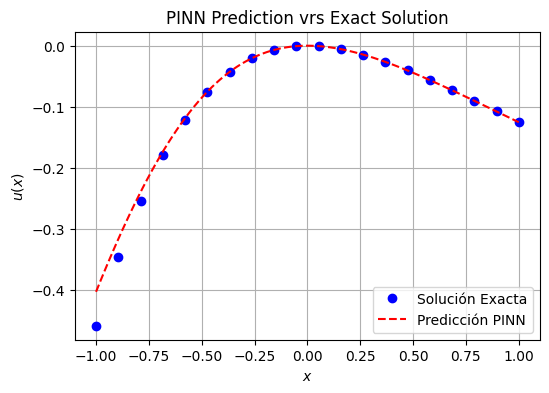

In [18]:
x_values_pinn = np.linspace(-1,1,100).reshape(-1,1)
y_pred        = model.predict(x_values_pinn)

x_values_exact = np.linspace(-1,1,20).reshape(-1,1)
y_exact        = func(x_values_exact)


plt.figure(figsize=(6,4))
plt.plot(x_values_exact,y_exact,'ob',label="Solución Exacta")

plt.plot(x_values_pinn,y_pred,'--r',label="Predicción PINN")

plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("PINN Prediction vrs Exact Solution")
plt.legend()
plt.grid()
plt.show()